In [1]:
import datetime
from typing import Any

import lightgbm as lgb
import numpy as np
import polars as pl
from numpy.typing import NDArray
from sklearn.metrics import (
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)

from polars_ml import Pipeline
from polars_ml.cv import date_series_split
from polars_ml.model import LightGBM
from polars_ml.transformer import LabelEncoding
from polars_ml.utils import get_country_holidays

pl.Config.set_tbl_rows(100)

train_df = pl.read_csv("../data/train.csv").cast({"date": pl.Date})
test_df = pl.read_csv("../data/test.csv").cast({"date": pl.Date})
gdp_df = pl.read_csv("../data/gdp.csv")

label = "num_sold"
countries = train_df["country"].unique().to_list()
stores = train_df["store"].unique().to_list()
products = train_df["product"].unique().to_list()

start_date: datetime.date = train_df["date"].min()  # type: ignore
end_date: datetime.date = test_df["date"].max()  # type: ignore
years = range(start_date.year, end_date.year + 1)

country_holidays = get_country_holidays(countries, years)
train_df = train_df.join(country_holidays, on=["date", "country"], how="left")
test_df = test_df.join(country_holidays, on=["date", "country"], how="left")


def make_pipeline(
    label_encoding: LabelEncoding,
    lightgbm_model: LightGBM,
) -> Pipeline:
    return (
        Pipeline()
        .select(pl.exclude("id"))
        .with_columns(
            pl.col("date").dt.day().alias("day"),
            pl.col("date").dt.weekday().alias("weekday"),
            pl.col("date").dt.month().alias("month"),
            pl.col("date").dt.year().alias("year"),
            (pl.col("date").dt.year() % 2).alias("is_even_year"),
            pl.col("holiday").is_null().not_().cast(pl.Int8),
        )
        .join(
            gdp_df.unpivot(index="year", variable_name="country", value_name="gdp"),
            on=["country", "year"],
            how="inner",
        )
        .group_by_then(
            ["country", "store", "product", "month"],
            pl.col(label).sum().alias("num_sold_by_month"),
        )
        .group_by_then(
            ["country", "store", "product", "weekday"],
            pl.col(label).sum().alias("num_sold_by_weekday"),
        )
        .pipe(label_encoding)
        .pipe(lightgbm_model)
    )


def symmetric_mean_absolute_percentage_error(
    y_true: NDArray[Any], y_pred: NDArray[Any]
) -> float:
    smape = (
        200
        / len(y_true)
        * np.sum(np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))
    )
    return float(smape)


def lightgbm_smape(pred: NDArray[Any], data: lgb.Dataset) -> tuple[str, float, bool]:
    y_true = data.get_label()
    smape_val = symmetric_mean_absolute_percentage_error(y_true, pred)  # type: ignore
    return "smape", smape_val, False


label_encoding = LabelEncoding("country", "store", "product")
lightgbm_model = LightGBM(
    pl.exclude("date", "year"),
    "num_sold",
    prediction_name="pred",
    params={"objective": "regression", "metric": "smape"},
    train_kwargs={
        "num_boost_round": 1000,
        "callbacks": [lgb.early_stopping(10), lgb.log_evaluation(10)],
        "feval": lightgbm_smape,
    },
    plot_importance=True,
    dir="./tmp",
)
model = make_pipeline(label_encoding, lightgbm_model)

cv_result: dict[str, list[Any]] = {}
for train_idx, valid_idx in date_series_split(
    train_df, "date", initial_days=365, period_days=365, horizon_days=365
):
    train_data = train_df.select(pl.all().gather(train_idx))
    valid_data = train_df.select(pl.all().gather(valid_idx))

    train_transformed_df = model.fit_transform(train_data, valid_data)
    valid_transformed_df = model.transform(valid_data)

    train_start_date = train_data["date"].min()
    train_end_date = train_data["date"].max()
    valid_start_date = valid_data["date"].min()
    valid_end_date = valid_data["date"].max()

    label_pred = valid_transformed_df.select(label, "pred").drop_nulls()
    label_np = label_pred[label].to_numpy()
    pred_np = label_pred["pred"].to_numpy()
    mape = mean_absolute_percentage_error(label_np, pred_np)
    smape = symmetric_mean_absolute_percentage_error(label_np, pred_np)
    rmse = root_mean_squared_error(label_np, pred_np)
    r2 = r2_score(label_np, pred_np)

    best_iteration = lightgbm_model.model.best_iteration

    cv_result.setdefault("train_start_date", []).append(train_start_date)
    cv_result.setdefault("train_end_date", []).append(train_end_date)
    cv_result.setdefault("valid_start_date", []).append(valid_start_date)
    cv_result.setdefault("valid_end_date", []).append(valid_end_date)
    cv_result.setdefault("mape", []).append(mape)
    cv_result.setdefault("smape", []).append(smape)
    cv_result.setdefault("rmse", []).append(rmse)
    cv_result.setdefault("r2", []).append(r2)
    cv_result.setdefault("best_iteration", []).append(best_iteration)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011503 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 586
[LightGBM] [Info] Number of data points in the train set: 32850, number of used features: 10
[LightGBM] [Info] Start training from score 673.801918
Training until validation scores don't improve for 10 rounds
[10]	train's smape: 54.8476	valid's smape: 57.0034
[20]	train's smape: 39.5725	valid's smape: 42.7002
[30]	train's smape: 29.3589	valid's smape: 33.72
[40]	train's smape: 22.0216	valid's smape: 27.5886
[50]	train's smape: 17.8301	valid's smape: 24.3445
[60]	train's smape: 16.3095	valid's smape: 23.4895
[70]	train's smape: 16.2996	valid's smape: 23.8791
Early stopping, best iteration is:
[61]	train's smape: 16.1312	valid's smape: 23.361
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012120 seconds.
You can set `force_col_wise=true` to remove the over

In [2]:
from polars import DataFrame

DataFrame(cv_result)

train_start_date,train_end_date,valid_start_date,valid_end_date,mape,smape,rmse,r2,best_iteration
date,date,date,date,f64,f64,f64,f64,i64
2010-01-01,2010-12-31,2011-01-01,2011-12-31,0.141143,15.468521,213.215697,0.922934,61
2010-01-01,2011-12-31,2012-01-01,2012-12-30,0.120275,12.050292,139.96205,0.962685,53
2010-01-01,2012-12-30,2012-12-31,2013-12-30,0.09437,9.227092,85.418093,0.987359,67
2010-01-01,2013-12-30,2013-12-31,2014-12-30,0.089641,8.933205,79.886429,0.987154,58
2010-01-01,2014-12-30,2014-12-31,2015-12-30,0.150022,14.247056,141.860587,0.947296,69


In [15]:
lightgbm_model = LightGBM(
    pl.exclude("date", "year"),
    "num_sold",
    prediction_name="pred",
    params={"objective": "regression", "metric": "mape"},
    train_kwargs={
        "num_boost_round": 100,
        "callbacks": [lgb.early_stopping(10), lgb.log_evaluation(10)],
        "feval": lightgbm_smape,
    },
    plot_importance=True,
    dir="./tmp",
)
model = make_pipeline(label_encoding, lightgbm_model)

model.fit(train_df)
test_transformed_df = model.transform(test_df)

submit_df = pl.read_csv("../data/sample_submission.csv")
submit_df.with_columns(test_transformed_df["pred"].rename("num_sold")).write_csv(
    "submit.csv"
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 114
[LightGBM] [Info] Number of data points in the train set: 230130, number of used features: 9
[LightGBM] [Info] Start training from score 723.519124


/root/polars-ml/.venv/lib/python3.12/site-packages/lightgbm/callback.py:341: UserWarning: Only training set found, disabling early stopping.
  _log_warning("Only training set found, disabling early stopping.")


[10]	train's mape: 15.0054
[20]	train's mape: 7.0768
[30]	train's mape: 3.92322
[40]	train's mape: 2.5973
[50]	train's mape: 2.07763
[60]	train's mape: 1.82659
[70]	train's mape: 1.59429
[80]	train's mape: 1.45712
[90]	train's mape: 1.37519
[100]	train's mape: 1.35232


In [16]:
!kaggle c submit -f submit.csv -m "submit-100" playground-series-s5e1

100%|██████████████████████████████████████| 2.39M/2.39M [00:01<00:00, 1.62MB/s]
Successfully submitted to Forecasting Sticker Sales

100%|██████████| 6/6 [00:00<00:00,  8.14it/s]


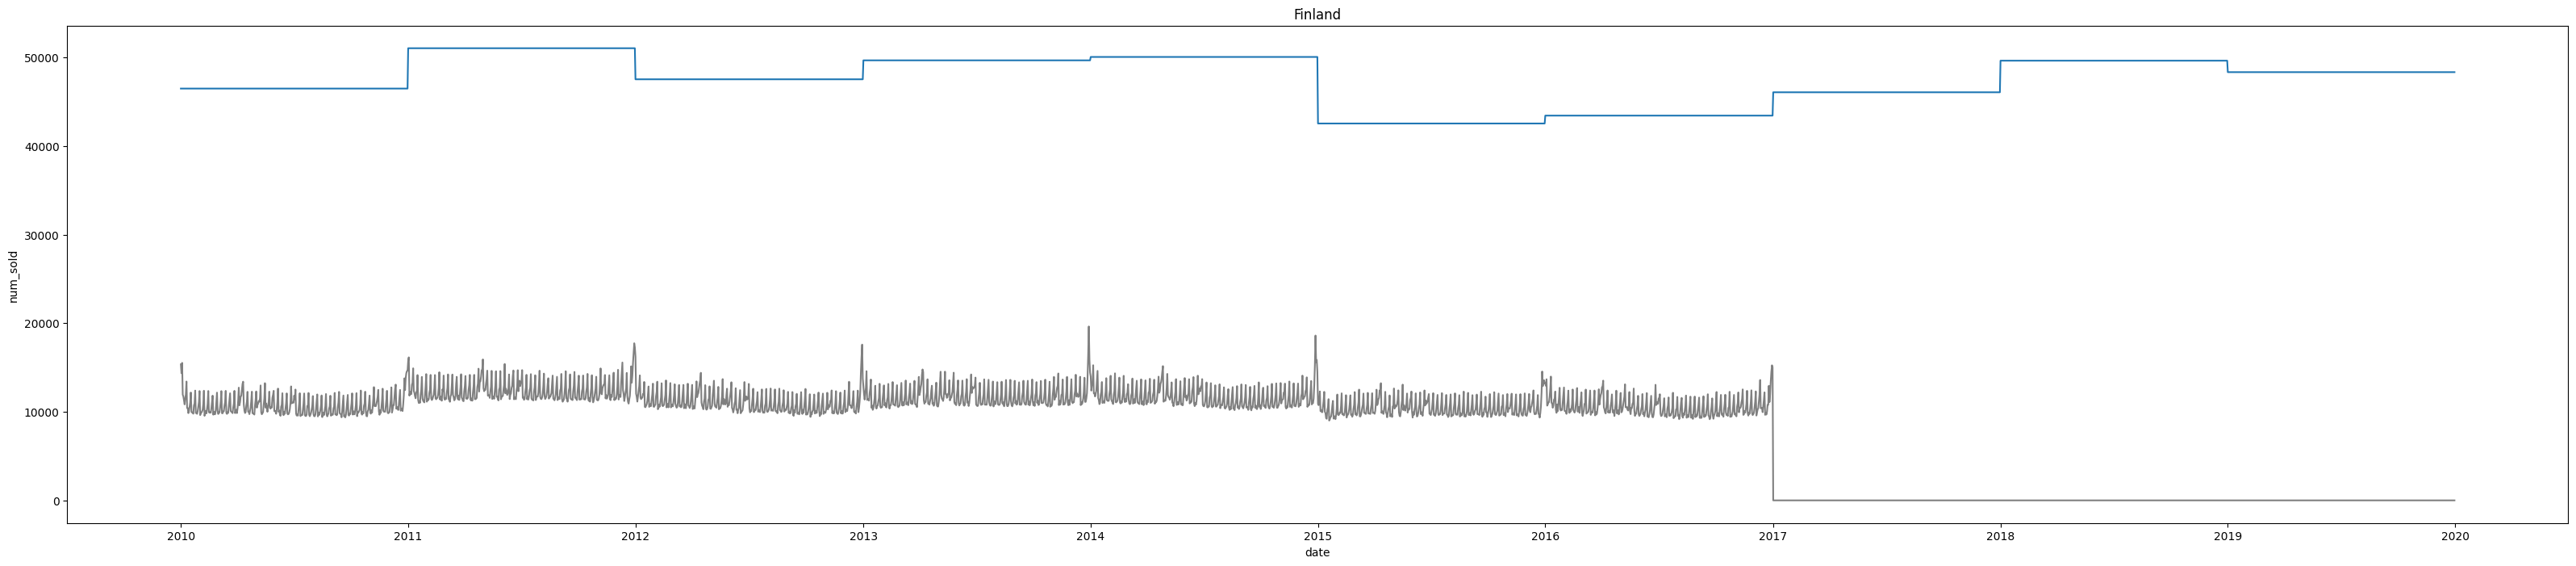

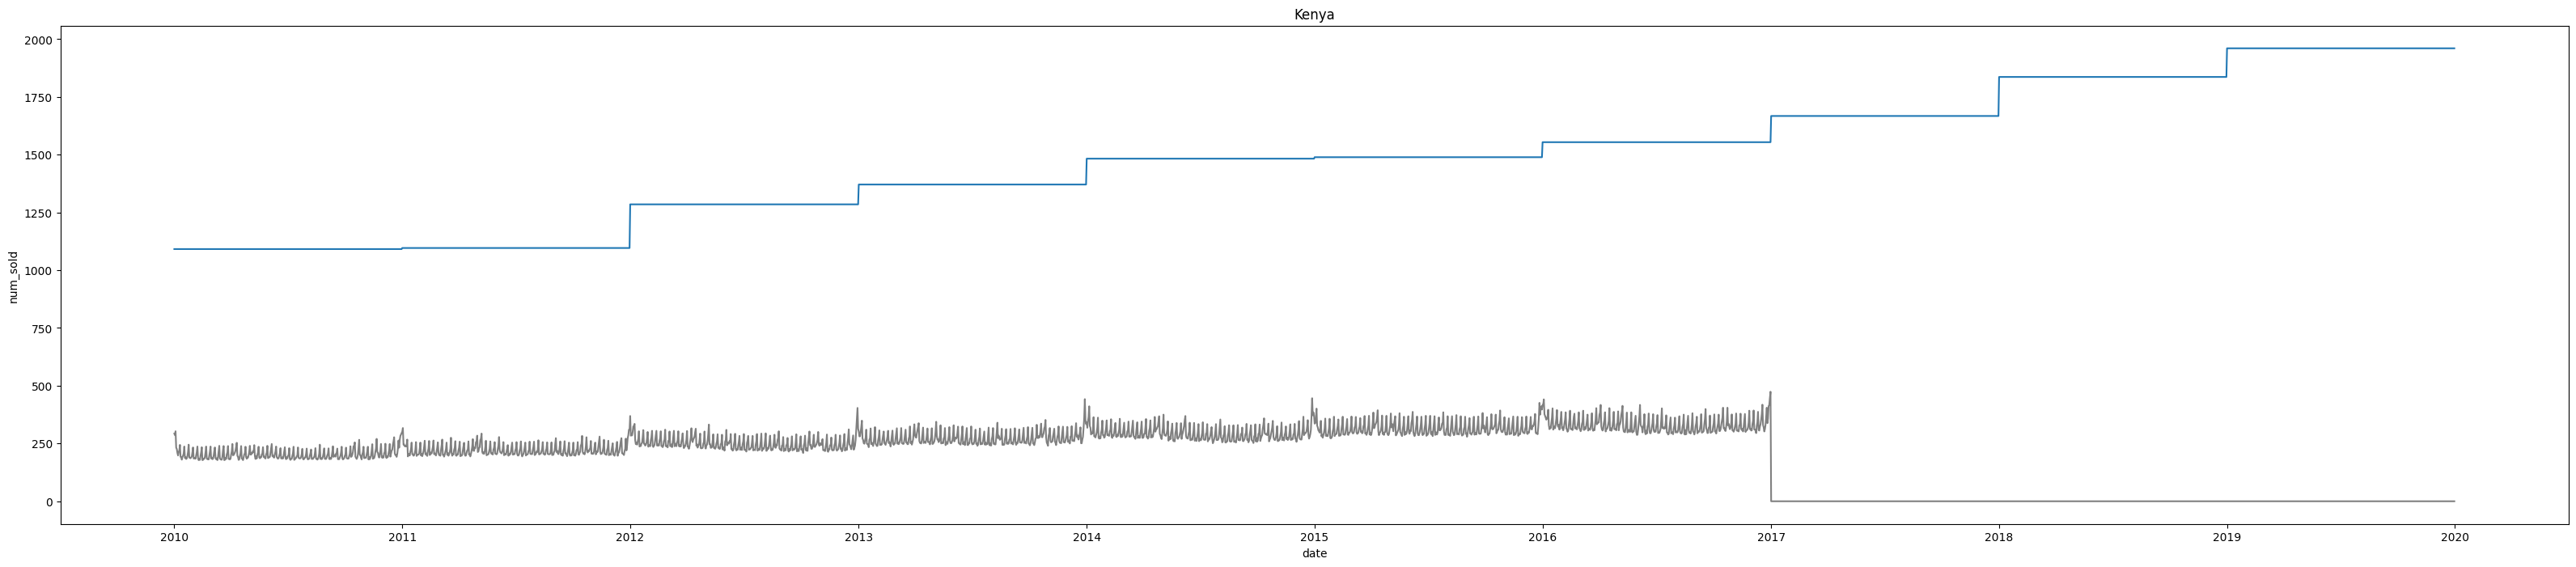

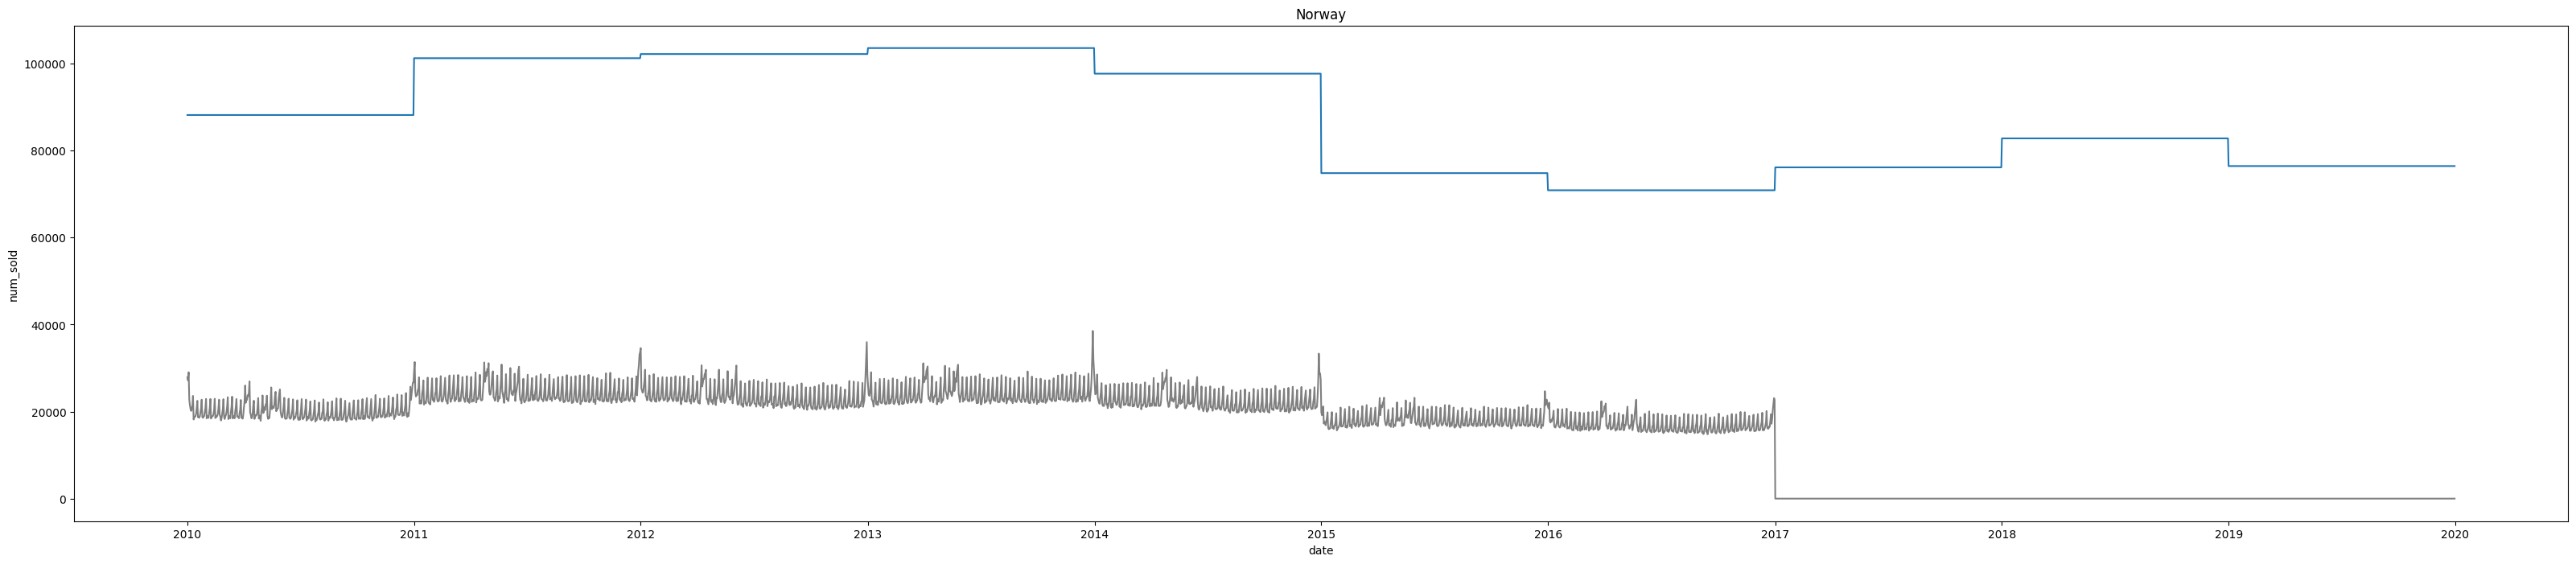

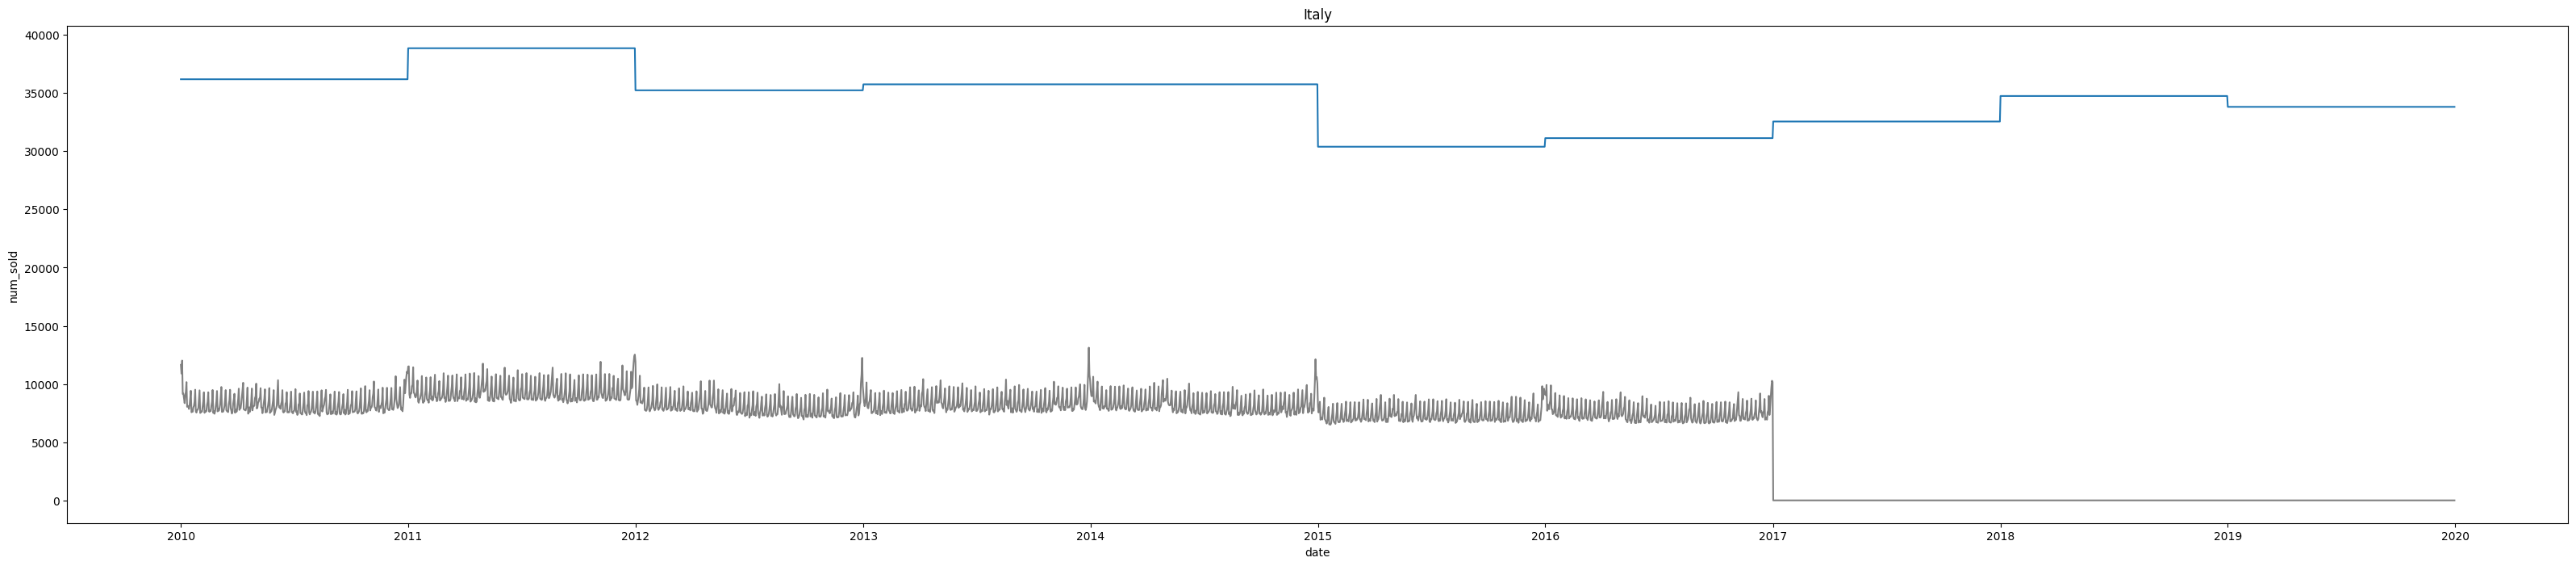

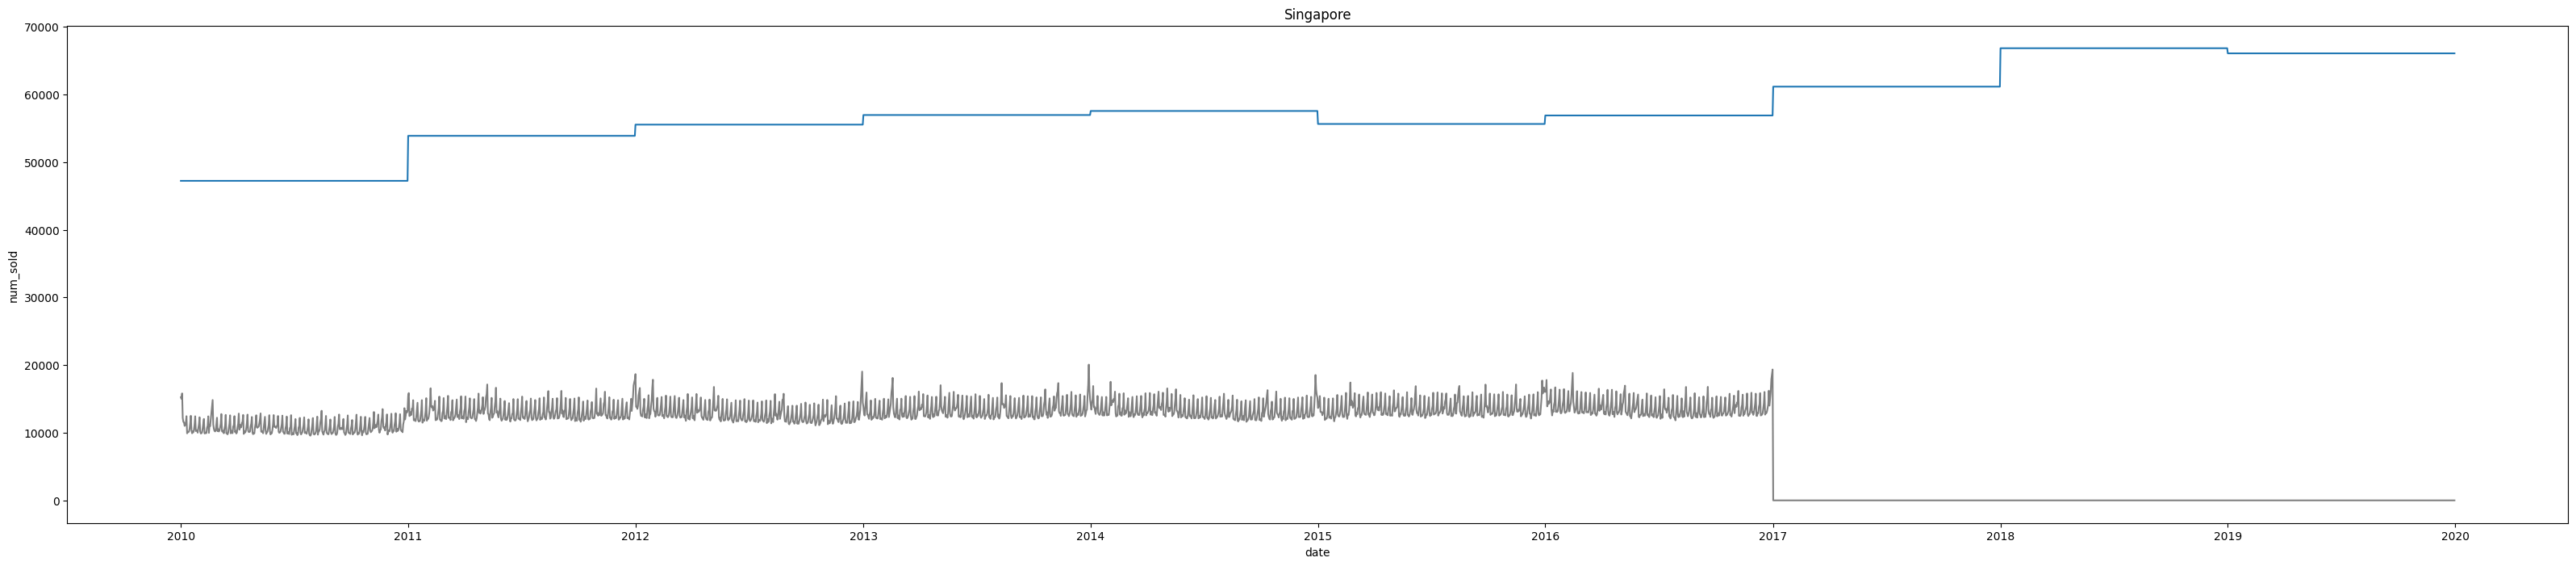

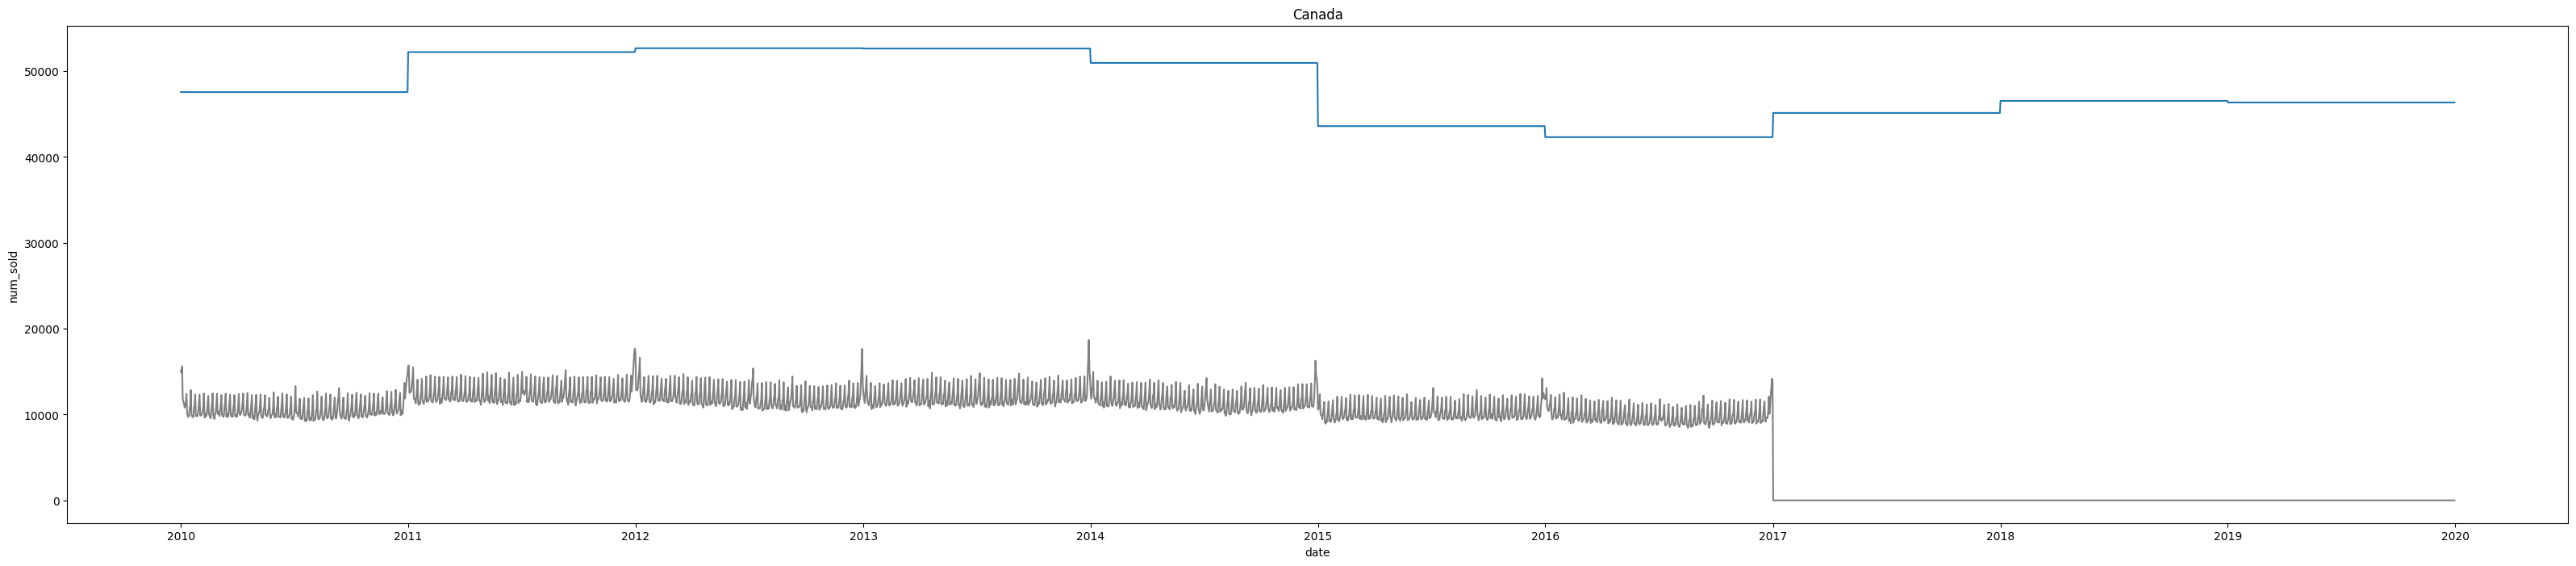

In [46]:
import itertools

import matplotlib.pyplot as plt
from tqdm import tqdm

df = pl.concat(
    [
        train_transformed_df,
        valid_transformed_df,
        test_transformed_df.with_columns(
            pl.lit(None).alias("num_sold"),
        ).select(train_transformed_df.columns),
    ]
)

if False:
    for country, store, product in itertools.product(countries, stores, products):
        data = label_encoding.inverse_transform(df)
        data = data.filter(
            (pl.col("country") == country)
            & (pl.col("store") == store)
            & (pl.col("product") == product)
        )

        fig, ax = plt.subplots(figsize=(40, 8))
        sns.scatterplot(data, x="date", y="num_sold", ax=ax, color="gray")
        sns.lineplot(data, x="date", y="lightgbm")

        plt.title(f"{country}-{store}-{product}")

if True:
    plt.close()
    for country in tqdm(countries):
        data = label_encoding.inverse_transform(df)
        data = (
            data.with_columns(pl.col("gdp").mean().alias("gdp_mean"))
            .group_by("date", "country", maintain_order=True)
            .agg(
                pl.sum("num_sold"),
                pl.sum("lightgbm"),
                pl.mean("gdp"),
            )
            .filter(pl.col("country") == country)
        )
        fig, ax = plt.subplots(figsize=(40, 8))
        sns.lineplot(data, x="date", y="num_sold", ax=ax, color="gray")
        # sns.lineplot(tmp, x="date", y="lightgbm")
        sns.lineplot(data, x="date", y="gdp")

        plt.title(f"{country}")

if False:
    plt.close()
    for store in tqdm(stores):
        data = label_encoding.inverse_transform(df)
        data = (
            data.group_by("date", "store", maintain_order=True)
            .agg(pl.sum("num_sold"), pl.sum("lightgbm"))
            .filter(pl.col("store") == store)
        )
        fig, ax = plt.subplots(figsize=(40, 8))
        sns.scatterplot(data, x="date", y="num_sold", ax=ax, color="gray")
        sns.lineplot(data, x="date", y="lightgbm")
        plt.title(f"{store}")
if False:
    plt.close()
    for product in tqdm(products):
        data = label_encoding.inverse_transform(df)
        data = (
            data.group_by("date", "product", maintain_order=True)
            .agg(pl.sum("num_sold"), pl.sum("lightgbm"))
            .filter(pl.col("product") == product)
        )
        fig, ax = plt.subplots(figsize=(40, 8))
        sns.scatterplot(data, x="date", y="num_sold", ax=ax, color="gray")
        sns.lineplot(data, x="date", y="lightgbm")
        plt.title(f"{product}")